# Biotech Portfolio PoTS Decision Engine

A Bayesian, portfolio-level decision engine for go/kill/repurpose decisions.

All data is simulated. This is a toy model to illustrate how adaptive Bayesian
updates can guide capital allocation decisions across a small portfolio of
biotech programs.

In [1]:
import sys, os
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

from engine import (
    load_portfolio, compute_pots, apply_interim, propagate_failure,
    smart_decision, capital_allocation, monte_carlo_portfolio,
    build_repurpose_table, value_of_information, stress_test, PHASE_THRESHOLDS,
)

os.makedirs('plots', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150})

## 1. Load Portfolio

In [2]:
df, repurpose_map, correlation = load_portfolio('data/assets.csv', 'data/repurpose_map.csv')
assets = df['asset'].tolist()
n = len(assets)
indications = df['indication'].tolist()
phases = df['phase'].tolist()
pathways = df['target_pathway'].tolist()
alpha_prior = df['prior_successes'].values + 1.0
beta_prior = df['prior_failures'].values + 1.0
revenue = df['estimated_revenue_m'].values.astype(float)
cost = df['estimated_cost_m'].values.astype(float)

display(df)
print(f'\nLoaded {n} assets')

,asset,phase,prior_successes,prior_failures,indication,estimated_revenue_m,estimated_cost_m,correlation_group,target_pathway
0,Asset A,Phase II,2,8,SLE,800,120,autoimmune,JAK-STAT
1,Asset B,Phase II,3,7,Lupus Nephritis,650,100,autoimmune,JAK-STAT
2,Asset C,Phase I,1,9,Type 2 Diabetes,1200,200,metabolic,Beta-cell / GLP-1
3,Asset D,Phase III,4,6,NAFLD,900,80,metabolic,Liver lipid metabolism
4,Asset E,Phase I,2,8,Rare Haem (PNH),500,150,haem,Complement C5



Loaded 5 assets


## 2. Prior PoTS Distributions

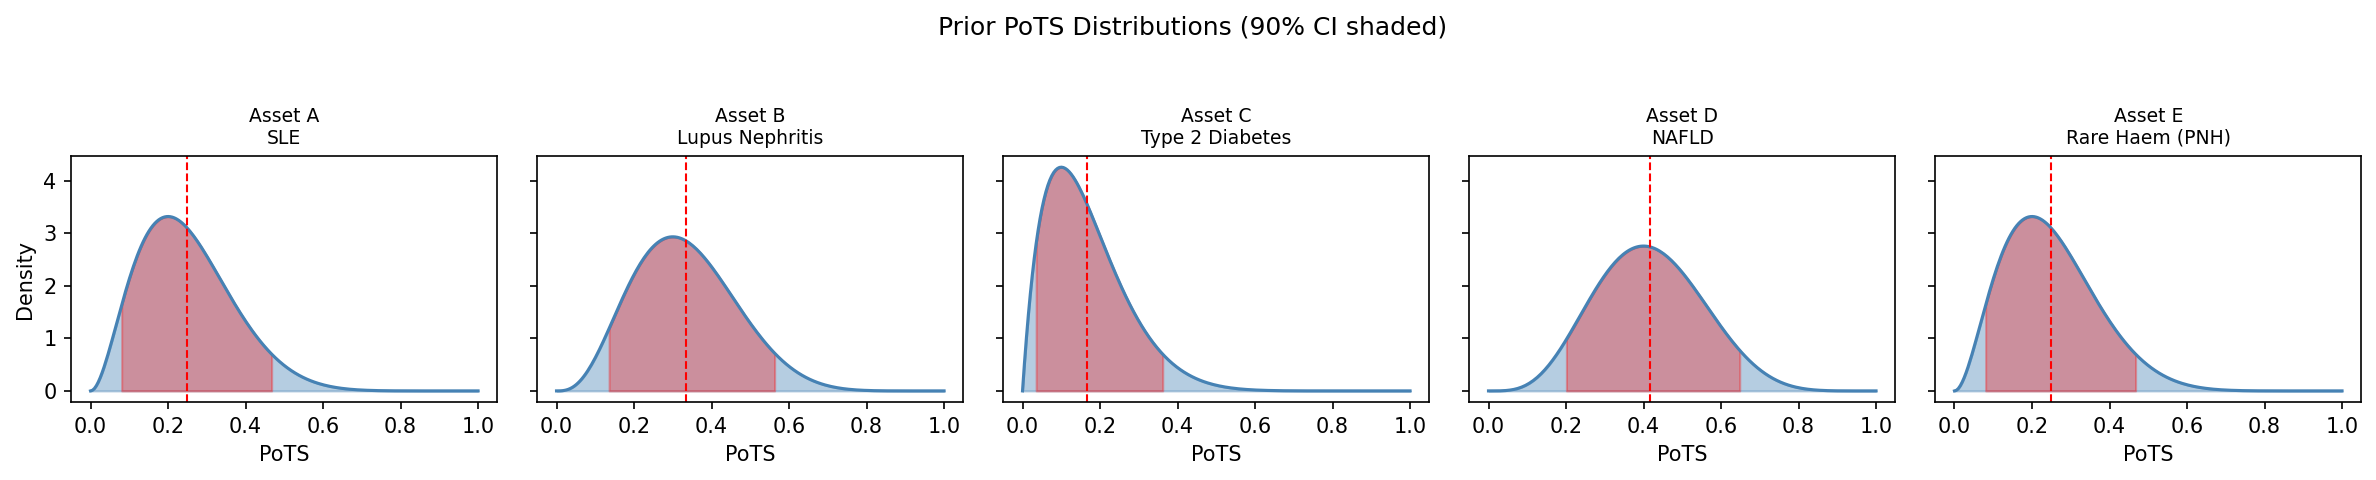

In [3]:
mean_prior, lo_prior, hi_prior = compute_pots(alpha_prior, beta_prior)
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, n, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    pdf = beta_dist.pdf(x, alpha_prior[i], beta_prior[i])
    ax.fill_between(x, pdf, alpha=0.4, color='steelblue')
    ax.plot(x, pdf, color='steelblue')
    ax.axvline(mean_prior[i], color='red', linestyle='--', linewidth=1)
    ax.fill_between(x, pdf, where=(x >= lo_prior[i]) & (x <= hi_prior[i]),
                    alpha=0.3, color='red')
    ax.set_title(f'{assets[i]}\n{indications[i]}', fontsize=9)
    ax.set_xlabel('PoTS')
axes[0].set_ylabel('Density')
fig.suptitle('Prior PoTS Distributions (90% CI shaded)', y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig('plots/prior_distributions.png', bbox_inches='tight')
plt.show()

## 3. Bayesian Updating After Interim Data

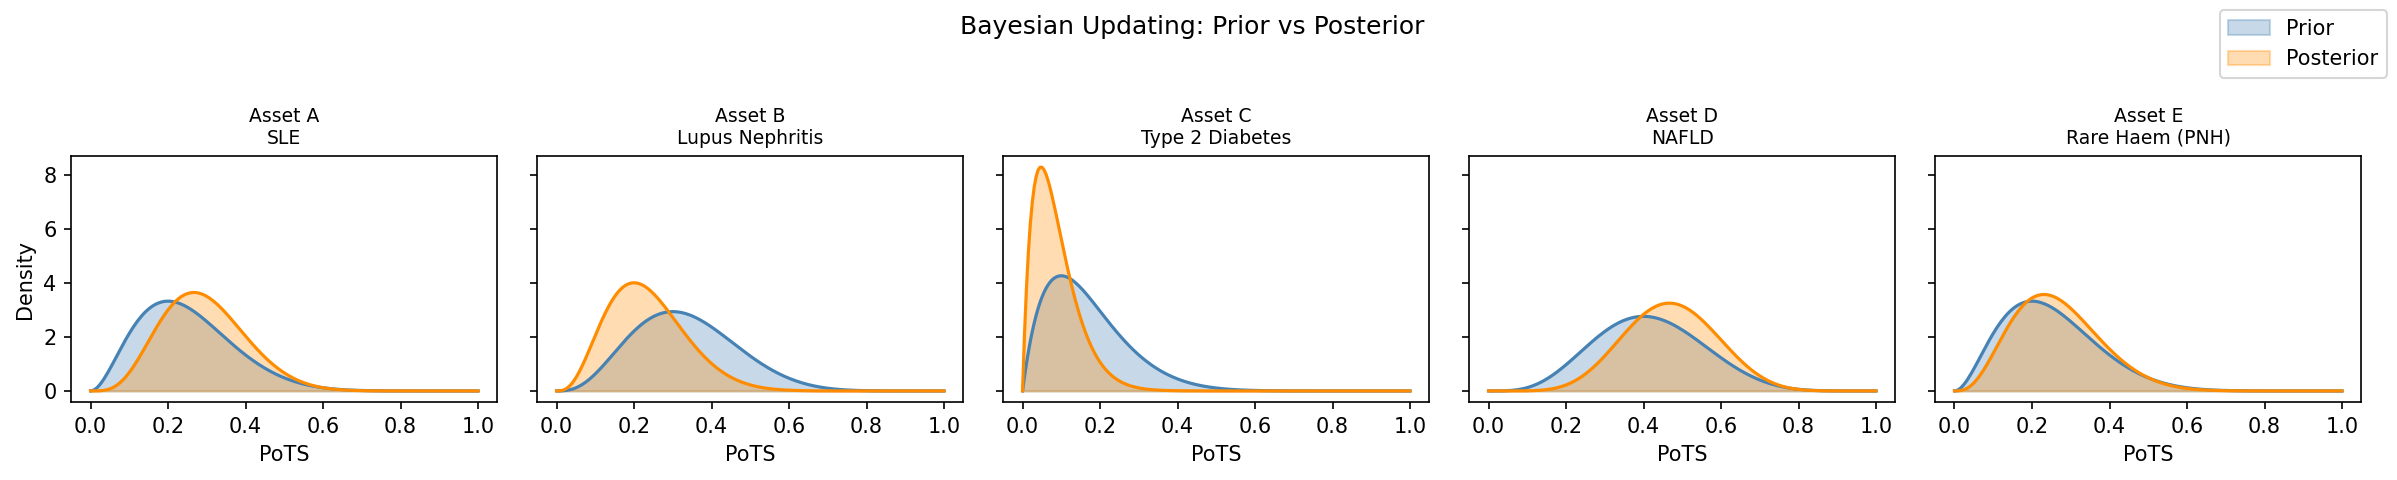

In [4]:
INTERIM = {
    'Asset A': (2, 5),   # 2/5 responders - modest but positive signal
    'Asset B': (0, 5),   # 0/5 - disappointing Phase II readout
    'Asset C': (0, 11),  # 0/11 - no signal in crowded T2D space
    'Asset D': (3, 5),   # 3/5 - strong late-stage data
    'Asset E': (1, 3),   # 1/3 - promising early signal on validated C5 target
}

alpha_post, beta_post = apply_interim(alpha_prior, beta_prior, assets, INTERIM)
mean_post, lo_post, hi_post = compute_pots(alpha_post, beta_post)

fig, axes = plt.subplots(1, n, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    pdf_prior = beta_dist.pdf(x, alpha_prior[i], beta_prior[i])
    pdf_post = beta_dist.pdf(x, alpha_post[i], beta_post[i])
    ax.fill_between(x, pdf_prior, alpha=0.3, color='steelblue', label='Prior' if i == 0 else None)
    ax.fill_between(x, pdf_post, alpha=0.3, color='darkorange', label='Posterior' if i == 0 else None)
    ax.plot(x, pdf_prior, color='steelblue')
    ax.plot(x, pdf_post, color='darkorange')
    ax.set_title(f'{assets[i]}\n{indications[i]}', fontsize=9)
    ax.set_xlabel('PoTS')
axes[0].set_ylabel('Density')
fig.legend(loc='upper right')
fig.suptitle('Bayesian Updating: Prior vs Posterior', y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig('plots/prior_vs_posterior.png', bbox_inches='tight')
plt.show()

## 4. Correlated Failure Propagation

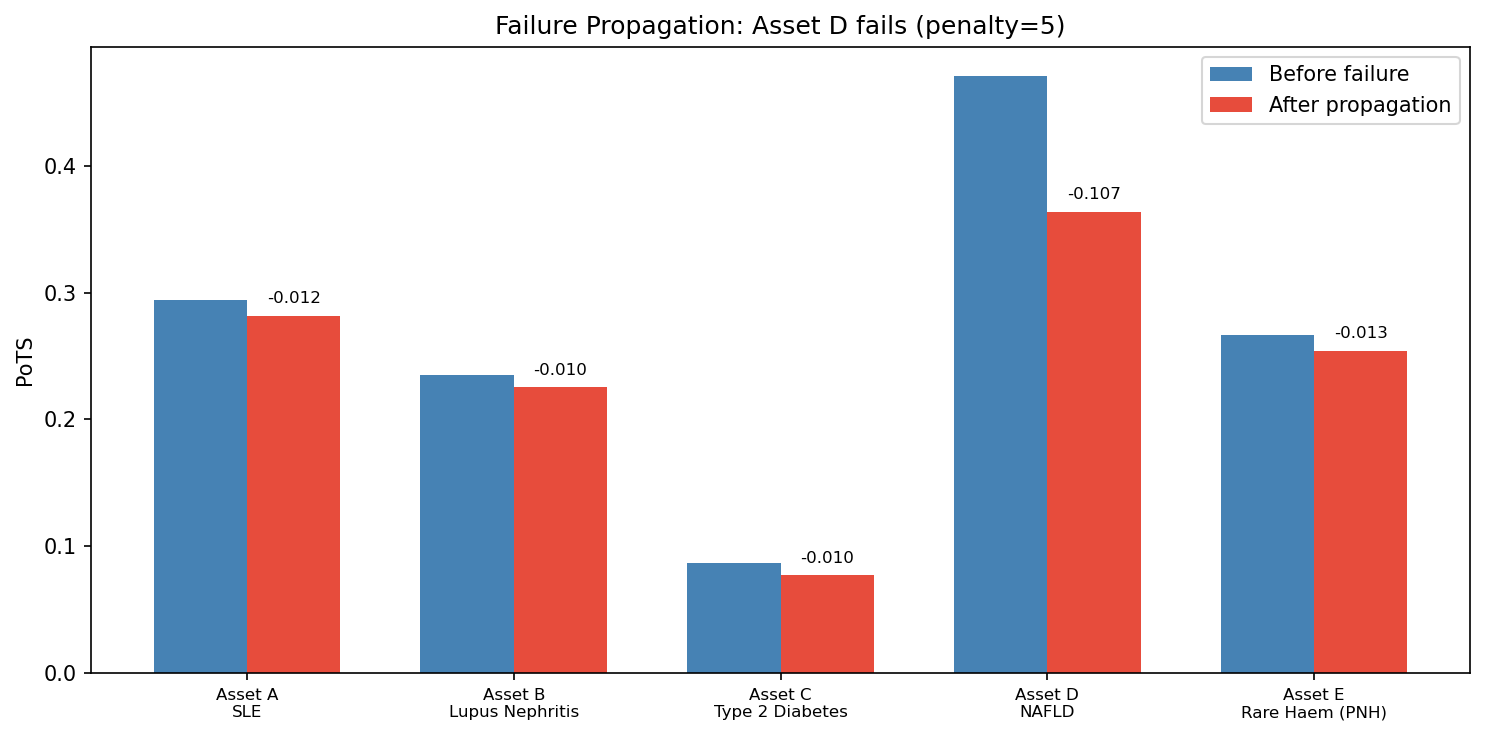

In [5]:
failed_idx = 3  # Asset D
penalty = 5
alpha_prop, beta_prop = propagate_failure(failed_idx, penalty, alpha_post, beta_post, correlation)
mean_prop, _, _ = compute_pots(alpha_prop, beta_prop)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(n)
w = 0.35
bars1 = ax.bar(x_pos - w/2, mean_post, w, label='Before failure', color='steelblue')
bars2 = ax.bar(x_pos + w/2, mean_prop, w, label='After propagation', color='#e74c3c')
for i in range(n):
    diff = mean_prop[i] - mean_post[i]
    ax.text(i + w/2, mean_prop[i] + 0.01, f'{diff:+.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{a}\n{ind}' for a, ind in zip(assets, indications)], fontsize=8)
ax.set_ylabel('PoTS')
ax.set_title(f'Failure Propagation: {assets[failed_idx]} fails (penalty={penalty})')
ax.legend()
fig.tight_layout()
fig.savefig('plots/failure_propagation.png', bbox_inches='tight')
plt.show()

## 5. Portfolio Decisions (Phase-Dependent Thresholds)

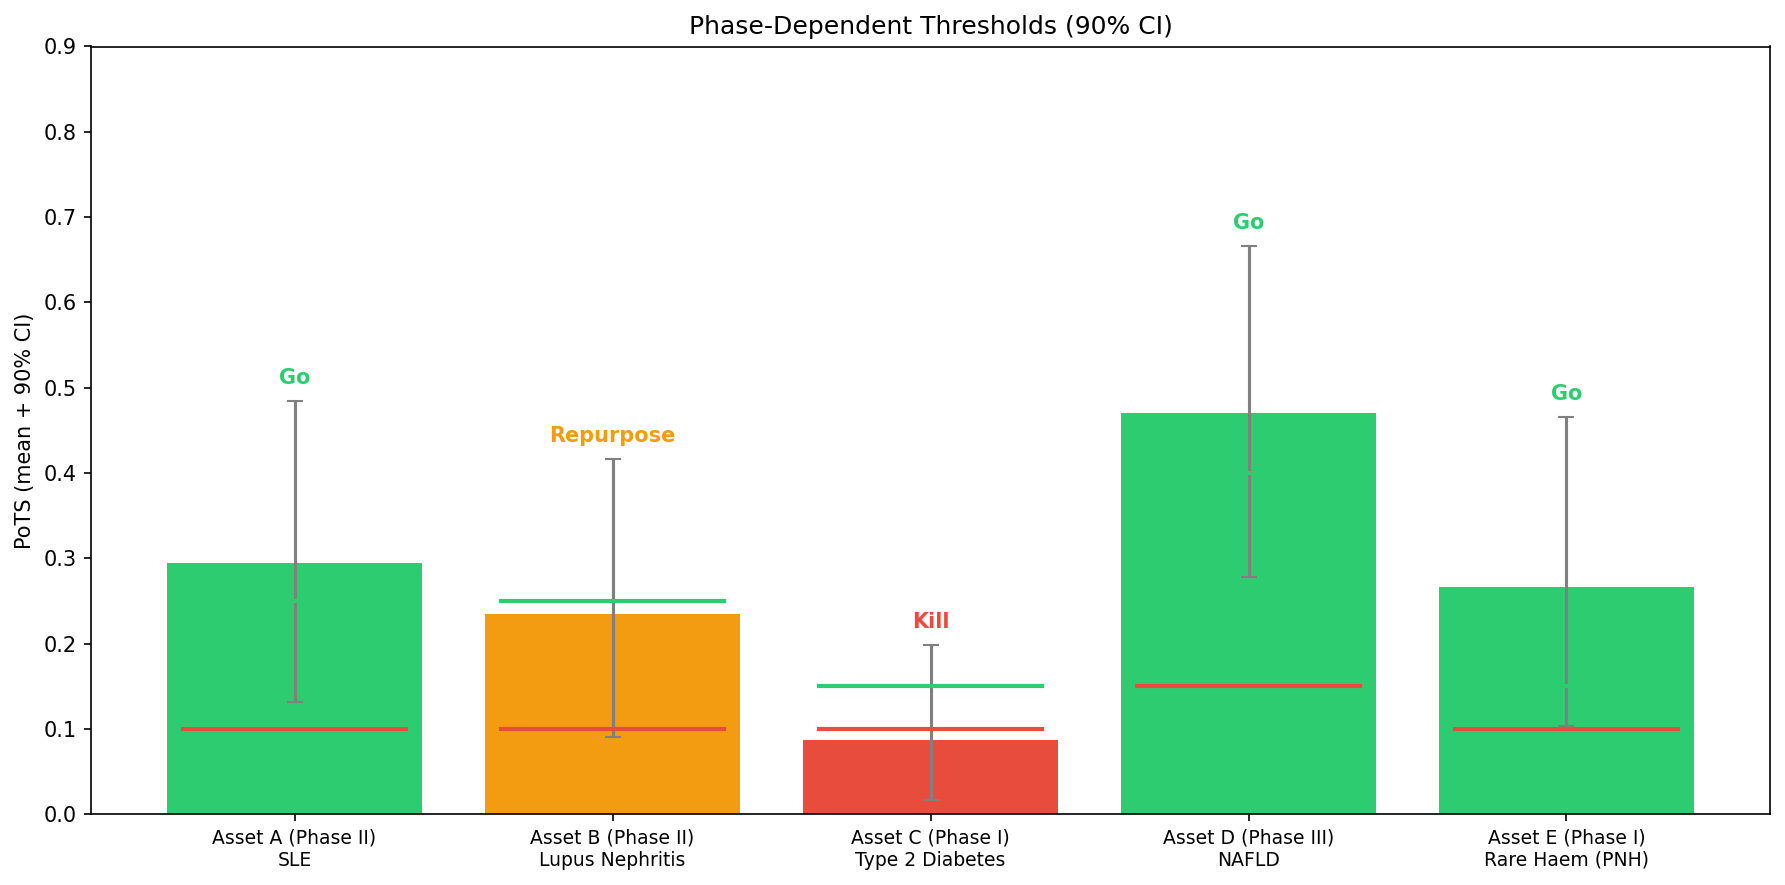

,Asset,Phase,Current Indication,PoTS,90% CI,Kill thresh,Go thresh,Decision,Suggested Repurpose,Repurpose PoTS,Reason
0,Asset A,Phase II,SLE,0.294,"[0.132, 0.484]",0.10,0.25,Go,-,-,-
1,Asset B,Phase II,Lupus Nephritis,0.235,"[0.090, 0.417]",0.10,0.25,Repurpose,SLE,0.176,Shared JAK-STAT pathway with systemic autoimmu...
2,Asset C,Phase I,Type 2 Diabetes,0.087,"[0.016, 0.198]",0.10,0.15,Kill,-,-,-
3,Asset D,Phase III,NAFLD,0.471,"[0.279, 0.667]",0.15,0.40,Go,-,-,-
4,Asset E,Phase I,Rare Haem (PNH),0.267,"[0.104, 0.466]",0.10,0.15,Go,-,-,-


In [6]:
thresh_scale = 1.0
decision_df = smart_decision(assets, phases, mean_post, lo_post, hi_post,
                              indications, repurpose_map, thresh_scale)

DEC_COLORS = {'Go': '#2ecc71', 'Kill': '#e74c3c', 'Repurpose': '#f39c12', 'Continue': '#3498db'}

fig, ax = plt.subplots(figsize=(12, 6))
colors = [DEC_COLORS[d] for d in decision_df['Decision']]
bars = ax.bar(range(n), mean_post, color=colors,
              yerr=[mean_post - lo_post, hi_post - mean_post],
              ecolor='grey', capsize=4)

for i in range(n):
    kt = decision_df['Kill thresh'].iloc[i]
    gt = decision_df['Go thresh'].iloc[i]
    ax.plot([i - 0.35, i + 0.35], [kt, kt], color='#e74c3c', linewidth=2)
    ax.plot([i - 0.35, i + 0.35], [gt, gt], color='#2ecc71', linewidth=2)
    ax.text(i, hi_post[i] + 0.02, decision_df['Decision'].iloc[i],
            ha='center', fontsize=10, fontweight='bold',
            color=DEC_COLORS[decision_df['Decision'].iloc[i]])

ax.set_xticks(range(n))
ax.set_xticklabels([f'{a} ({ph})\n{ind}' for a, ind, ph in zip(assets, indications, phases)],
                    fontsize=9)
ax.set_ylabel('PoTS (mean + 90% CI)')
ax.set_ylim(0, 0.9)
ax.set_title('Phase-Dependent Thresholds (90% CI)')
fig.tight_layout()
fig.savefig('plots/portfolio_decisions.png', bbox_inches='tight')
plt.show()

display(decision_df[['Asset', 'Phase', 'Current Indication', 'PoTS', '90% CI',
                      'Kill thresh', 'Go thresh', 'Decision',
                      'Suggested Repurpose', 'Repurpose PoTS', 'Reason']])

## 6. Capital Allocation

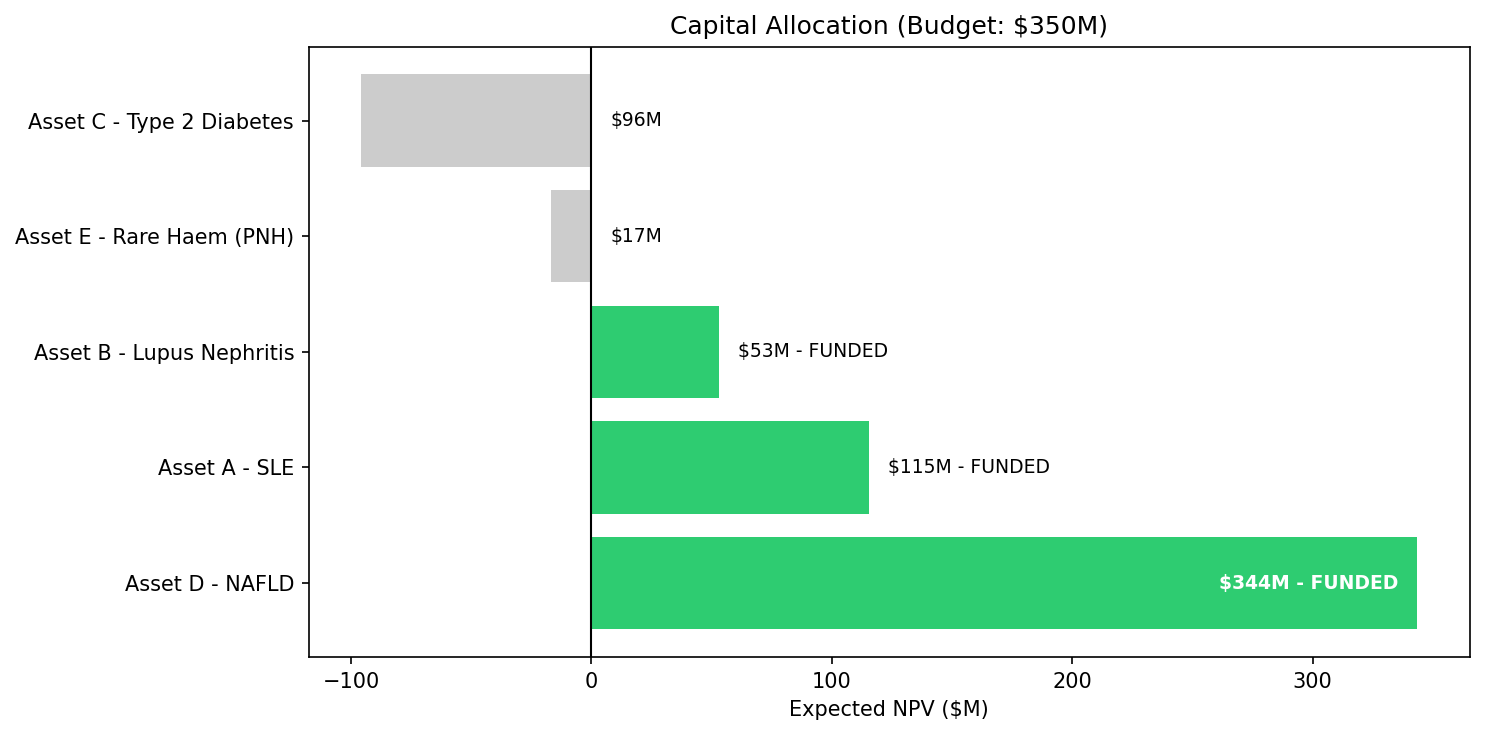

Budget: $350M | Allocated: $300M | Remaining: $50M


In [7]:
budget = 350
enpv, funded, remaining = capital_allocation(mean_post, revenue, cost, budget)

order = np.argsort(-enpv)
max_enpv = max(abs(enpv))

fig, ax = plt.subplots(figsize=(10, 5))
y_labels = [f'{assets[i]} - {indications[i]}' for i in order]
bar_colors = ['#2ecc71' if funded[i] else '#cccccc' for i in order]
ax.barh(y_labels, enpv[order], color=bar_colors)
ax.axvline(x=0, color='black', linewidth=1)

for j, i in enumerate(order):
    val = enpv[i]
    label = f'{chr(36)}{abs(val):.0f}M'
    if funded[i]:
        label += ' - FUNDED'
    if val > max_enpv * 0.4:
        ax.text(val - 8, j, label, va='center', ha='right',
                fontsize=9, fontweight='bold', color='white')
    else:
        ax.text(max(val, 0) + 8, j, label, va='center', ha='left', fontsize=9)

ax.set_xlabel('Expected NPV ({})'.format(chr(36) + 'M'))
ax.set_title(f'Capital Allocation (Budget: {chr(36)}{budget}M)')
fig.tight_layout()
fig.savefig('plots/capital_allocation.png', bbox_inches='tight')
plt.show()

print(f'Budget: {chr(36)}{budget}M | Allocated: {chr(36)}{budget - remaining:.0f}M | Remaining: {chr(36)}{remaining:.0f}M')

## 7. Monte Carlo Portfolio Simulation

Median: $250M
5th percentile: -$650M
95th percentile: $1.7B
P(positive): 68%


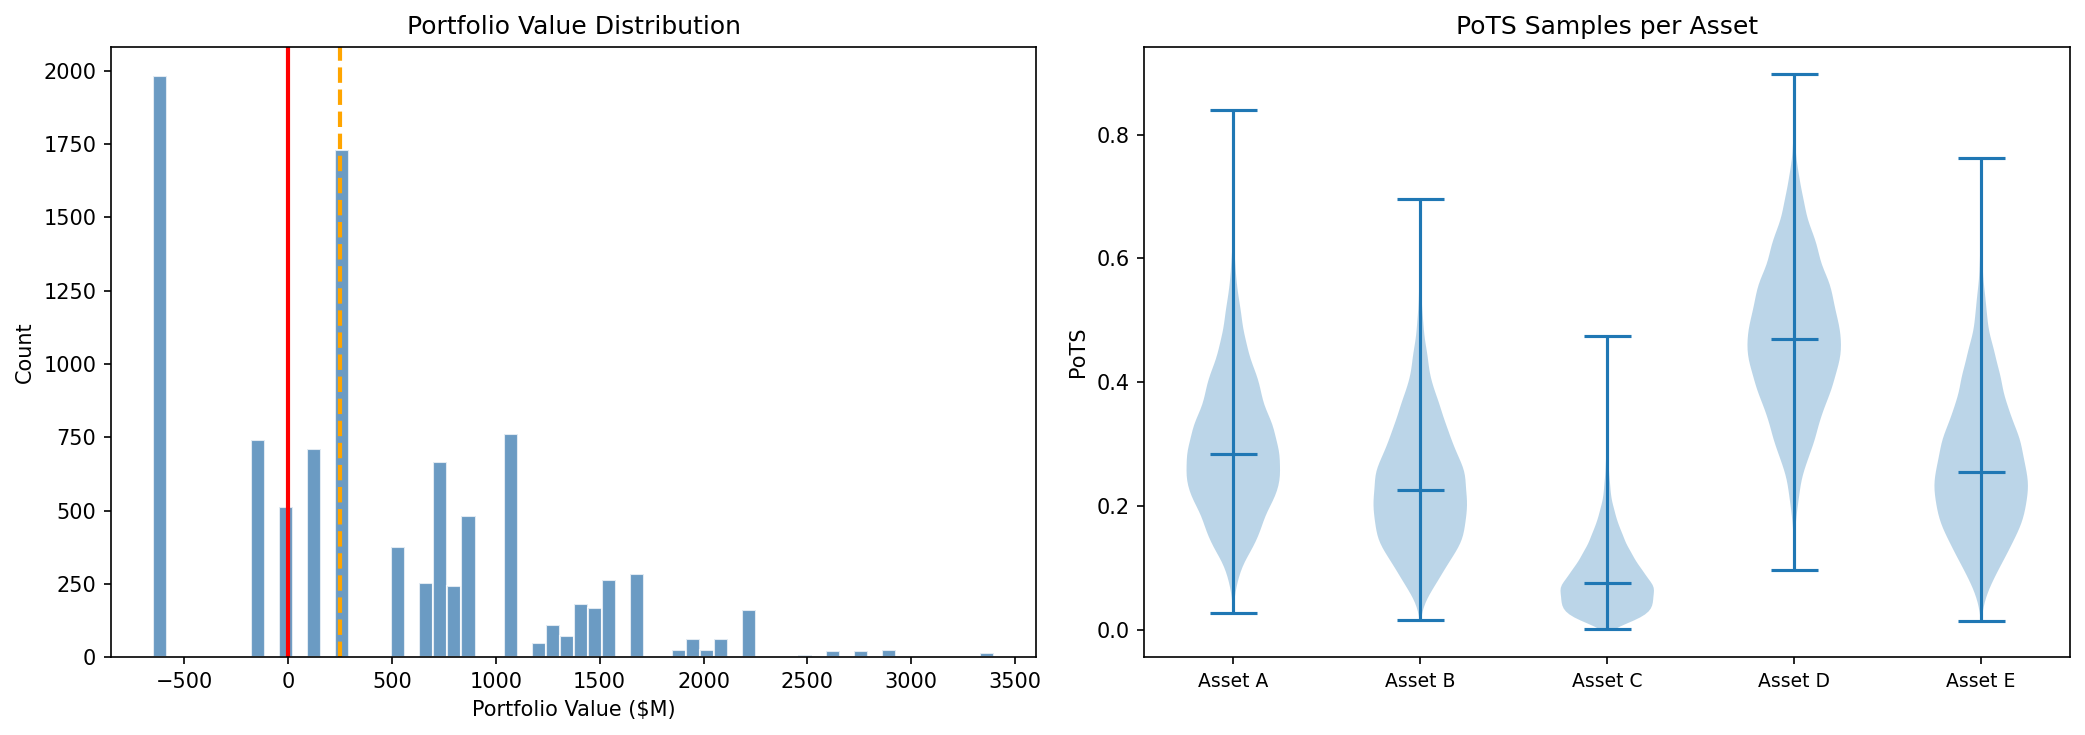

In [8]:
n_sims = 10000
pots_samples, portfolio_value = monte_carlo_portfolio(
    alpha_post, beta_post, correlation, revenue, cost, n_sims)

median_val = np.median(portfolio_value)
p5 = np.percentile(portfolio_value, 5)
p95 = np.percentile(portfolio_value, 95)

def fmt_money(v):
    neg = v < 0
    av = abs(v)
    s = f'{chr(36)}{av/1000:.1f}B' if av >= 1000 else f'{chr(36)}{av:.0f}M'
    return f'-{s}' if neg else s

print(f'Median: {fmt_money(median_val)}')
print(f'5th percentile: {fmt_money(p5)}')
print(f'95th percentile: {fmt_money(p95)}')
print(f'P(positive): {(portfolio_value > 0).mean():.0%}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(portfolio_value, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(0, color='red', linewidth=2)
ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Portfolio Value ({})'.format(chr(36) + 'M'))
ax1.set_ylabel('Count')
ax1.set_title('Portfolio Value Distribution')

ax2.violinplot([pots_samples[:, i] for i in range(n)], positions=range(n), showmedians=True)
ax2.set_xticks(range(n))
ax2.set_xticklabels(assets, fontsize=9)
ax2.set_ylabel('PoTS')
ax2.set_title('PoTS Samples per Asset')

fig.tight_layout()
fig.savefig('plots/monte_carlo.png', bbox_inches='tight')
plt.show()

## 8. Correlation Heatmap

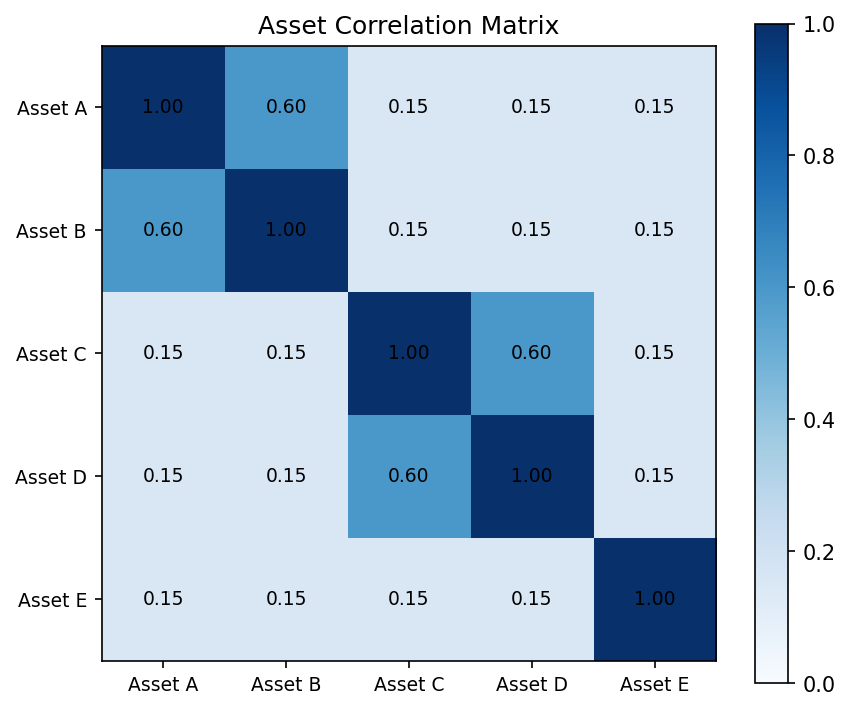

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlation, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(assets, fontsize=9)
ax.set_yticklabels(assets, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{correlation[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im)
ax.set_title('Asset Correlation Matrix')
fig.tight_layout()
fig.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Repurposing Landscape

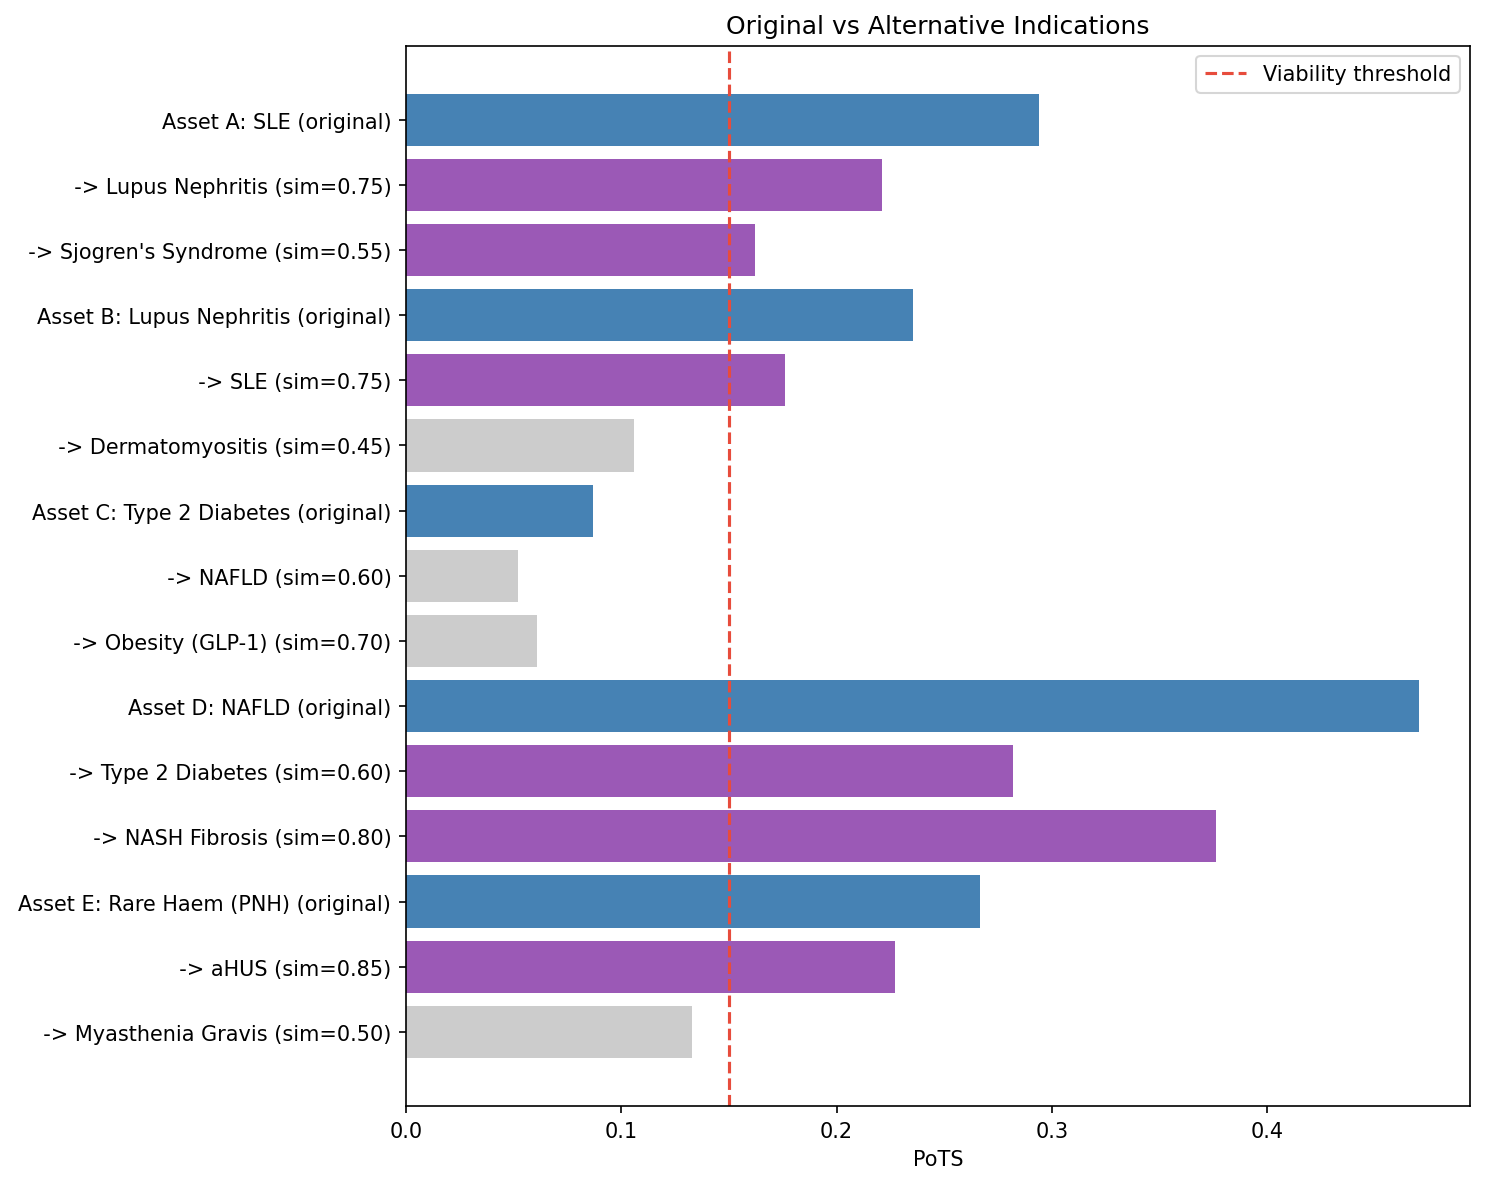

,Asset,Original Indication,Original PoTS,Alt Indication,Similarity,Repurpose PoTS,Viable,Reason
0,Asset A,SLE,0.294,Lupus Nephritis,0.75,0.221,True,Shared JAK-STAT pathway with renal inflammation
1,Asset A,SLE,0.294,Sjogren's Syndrome,0.55,0.162,True,Autoimmune overlap via B-cell activation
2,Asset B,Lupus Nephritis,0.235,SLE,0.75,0.176,True,Shared JAK-STAT pathway with systemic autoimmu...
3,Asset B,Lupus Nephritis,0.235,Dermatomyositis,0.45,0.106,False,Partial immune overlap
4,Asset C,Type 2 Diabetes,0.087,NAFLD,0.60,0.052,False,Beta-cell stress and hepatic lipid metabolism ...
5,Asset C,Type 2 Diabetes,0.087,Obesity (GLP-1),0.70,0.061,False,Direct GLP-1 receptor agonism
6,Asset D,NAFLD,0.471,Type 2 Diabetes,0.60,0.282,True,Liver-pancreas metabolic axis
7,Asset D,NAFLD,0.471,NASH Fibrosis,0.80,0.376,True,Same hepatic lipid target with fibrotic endpoint
8,Asset E,Rare Haem (PNH),0.267,aHUS,0.85,0.227,True,Same complement C5 target different disease
9,Asset E,Rare Haem (PNH),0.267,Myasthenia Gravis,0.50,0.133,False,Complement-mediated autoimmune


In [10]:
repurpose_df = build_repurpose_table(assets, indications, mean_post, repurpose_map)

y_labels_rep = []
y_values_rep = []
y_colors_rep = []
for i, asset in enumerate(assets):
    y_labels_rep.append(f'{asset}: {indications[i]} (original)')
    y_values_rep.append(mean_post[i])
    y_colors_rep.append('steelblue')
    cands = repurpose_df[repurpose_df['Asset'] == asset]
    for _, row in cands.iterrows():
        y_labels_rep.append(f"  -> {row['Alt Indication']} (sim={row['Similarity']:.2f})")
        y_values_rep.append(row['Repurpose PoTS'])
        y_colors_rep.append('#9b59b6' if row['Viable'] else '#cccccc')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y_labels_rep, y_values_rep, color=y_colors_rep)
ax.axvline(x=0.15, color='#e74c3c', linestyle='--', label='Viability threshold')
ax.set_xlabel('PoTS')
ax.set_title('Original vs Alternative Indications')
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
fig.savefig('plots/repurpose_landscape.png', bbox_inches='tight')
plt.show()

display(repurpose_df)

## 10. Value of Information Analysis

For each asset, how many additional patients would we need to enroll before the
decision resolves (escapes the Continue zone)?  The Beta-Binomial predictive
distribution lets us enumerate every possible trial outcome at each sample size
and compute:

- **Decision resolution probability** - chance that the updated posterior mean
  crosses a Go or Kill threshold
- **EVSI (Expected Value of Sample Information)** - the dollar value of running
  N more patients before committing capital

Assets already in the Go or Kill zone have low VoI - we already know what to do.
Continue-zone assets are where additional data has the highest payoff.

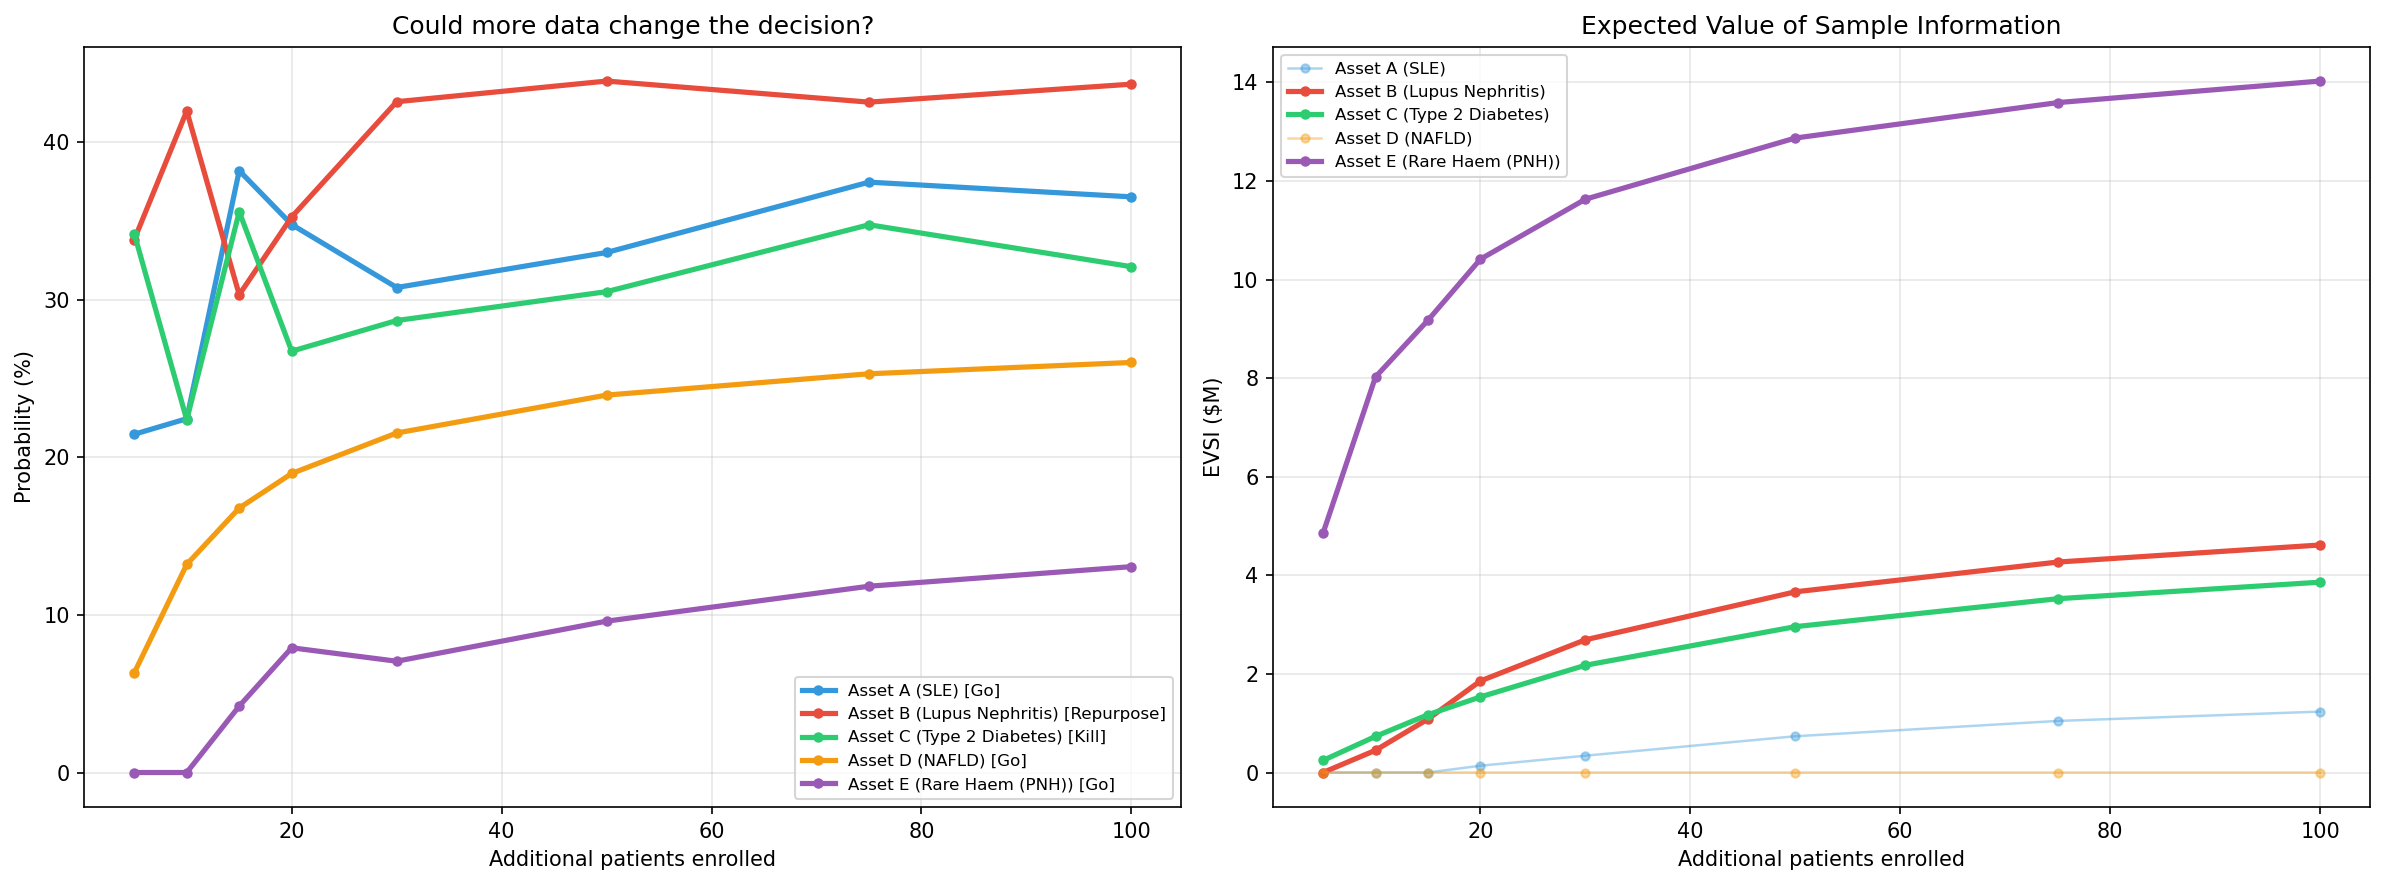

,Asset,Indication,Phase,Current Decision,PoTS,P(flip) at N=20,Peak EVSI ($M),Peak at N
0,Asset A,SLE,Phase II,Go,0.294,35%,1.2,100
1,Asset B,Lupus Nephritis,Phase II,Repurpose,0.235,35%,4.6,100
2,Asset C,Type 2 Diabetes,Phase I,Kill,0.087,27%,3.9,100
3,Asset D,NAFLD,Phase III,Go,0.471,19%,0.0,100
4,Asset E,Rare Haem (PNH),Phase I,Go,0.267,8%,14.0,100



--- Value of Information Summary ---

Asset A (Go): Moderate VoI ($1M). 35% chance of flip with 20 more patients.
Asset B (Repurpose): Moderate VoI ($5M). 35% chance of flip with 20 more patients.
Asset C (Kill): Moderate VoI ($4M). 27% chance of flip with 20 more patients.
Asset D (Go): Decision is robust. Additional data worth <$1M.
Asset E (Go): HIGH VoI ($14M). Data is thin - 8% chance of flip with 20 more patients. Consider enrolling ~100 more before committing.


In [11]:
sample_sizes = np.array([5, 10, 15, 20, 30, 50, 75, 100])
voi_results, sample_sizes = value_of_information(
    alpha_post, beta_post, phases, revenue, cost, sample_sizes)

decisions = decision_df['Decision'].tolist()
asset_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# --- Plot 1: Probability current decision FLIPS with more data ---
# For Go assets: P(new_mean < go_t). For Kill: P(new_mean > kill_t).
# For Continue/Repurpose: P(crosses either threshold) = resolution prob.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i in range(n):
    res = voi_results[i]
    dec = decisions[i]
    if dec in ('Go',):
        flip_prob = 1 - res['go_prob']  # P(would NOT go)
    elif dec == 'Kill':
        flip_prob = 1 - res['kill_prob']  # P(would NOT kill)
    else:
        flip_prob = res['resolution_prob']  # P(escapes Continue zone)

    lw = 2.5 if flip_prob.max() > 0.10 else 1.2
    alpha_line = 1.0 if flip_prob.max() > 0.10 else 0.4
    ax1.plot(sample_sizes, flip_prob * 100,
             '-', color=asset_colors[i], linewidth=lw, alpha=alpha_line,
             marker='o', markersize=4,
             label=f"{assets[i]} ({indications[i]}) [{dec}]")

ax1.set_xlabel('Additional patients enrolled')
ax1.set_ylabel('Probability (%)')
ax1.set_title('Could more data change the decision?')
ax1.legend(fontsize=8, loc='best')
ax1.grid(alpha=0.3)

# --- Plot 2: EVSI in $M ---
for i in range(n):
    res = voi_results[i]
    dec = decisions[i]
    lw = 2.5 if res['evsi'].max() > 2.0 else 1.2
    alpha_line = 1.0 if res['evsi'].max() > 2.0 else 0.4
    ax2.plot(sample_sizes, res['evsi'],
             '-', color=asset_colors[i], linewidth=lw, alpha=alpha_line,
             marker='o', markersize=4,
             label=f"{assets[i]} ({indications[i]})")

ax2.set_xlabel('Additional patients enrolled')
ax2.set_ylabel('EVSI ({}M)'.format(chr(36)))
ax2.set_title('Expected Value of Sample Information')
ax2.legend(fontsize=8, loc='best')
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('plots/value_of_information.png', bbox_inches='tight')
plt.show()

# --- Summary table ---
rows = []
for i in range(n):
    res = voi_results[i]
    dec = decisions[i]
    if dec in ('Go',):
        flip_prob = 1 - res['go_prob']
    elif dec == 'Kill':
        flip_prob = 1 - res['kill_prob']
    else:
        flip_prob = res['resolution_prob']

    peak_evsi = res['evsi'].max()
    peak_n = int(sample_sizes[res['evsi'].argmax()])
    flip_at_20 = flip_prob[sample_sizes == 20][0] * 100 if 20 in sample_sizes else None

    rows.append({
        'Asset': assets[i],
        'Indication': indications[i],
        'Phase': phases[i],
        'Current Decision': dec,
        'PoTS': f"{res['current_mean']:.3f}",
        'P(flip) at N=20': f"{flip_at_20:.0f}%",
        f'Peak EVSI ({chr(36)}M)': f"{peak_evsi:.1f}",
        'Peak at N': peak_n,
    })

voi_df = pd.DataFrame(rows)
display(voi_df)

# Actionable narrative
print('\n--- Value of Information Summary ---\n')
for _, row in voi_df.iterrows():
    asset = row['Asset']
    dec = row['Current Decision']
    evsi = float(row[f'Peak EVSI ({chr(36)}M)'])
    flip = row['P(flip) at N=20']
    peak_n = row['Peak at N']

    if evsi < 1.0:
        print(f"{asset} ({dec}): Decision is robust. Additional data worth <{chr(36)}1M.")
    elif evsi < 5.0:
        print(f"{asset} ({dec}): Moderate VoI ({chr(36)}{evsi:.0f}M). "
              f"{flip} chance of flip with 20 more patients.")
    else:
        print(f"{asset} ({dec}): HIGH VoI ({chr(36)}{evsi:.0f}M). "
              f"Data is thin - {flip} chance of flip with 20 more patients. "
              f"Consider enrolling ~{peak_n} more before committing.")

## 11. Scenario Stress Test

How sensitive is the portfolio to the assumptions we made?  Each bar in the
tornado diagram shows how much the median portfolio value shifts when a single
assumption moves from its low to its high bound - all else equal.

The scenario table then combines the assumptions into Bear / Base / Bull cases
to show the full distribution spread.

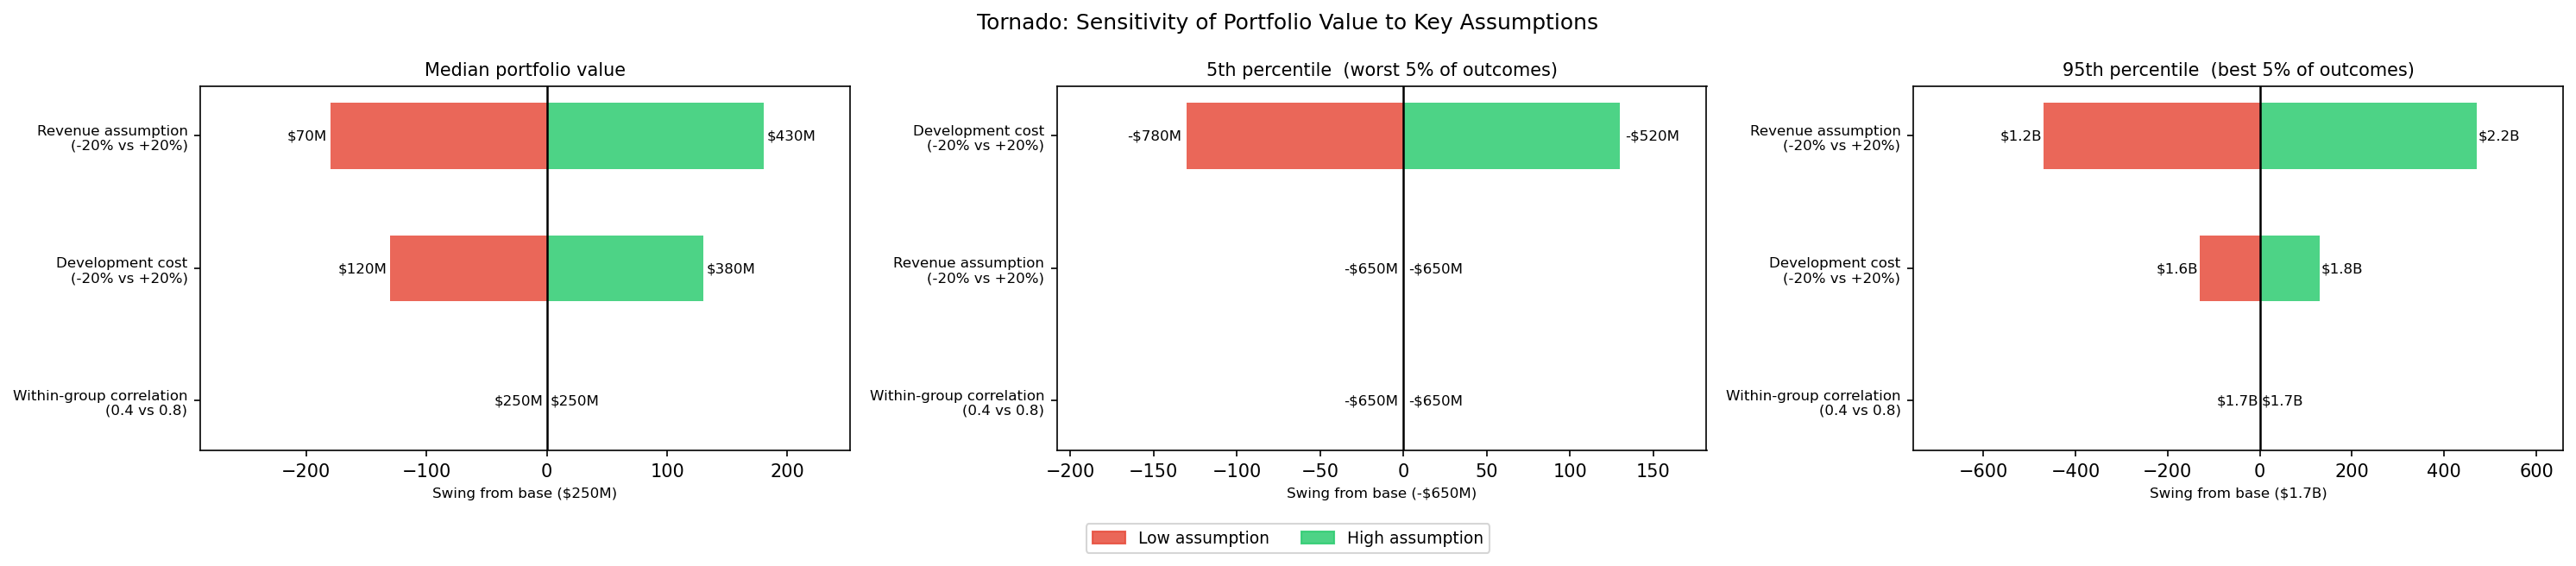

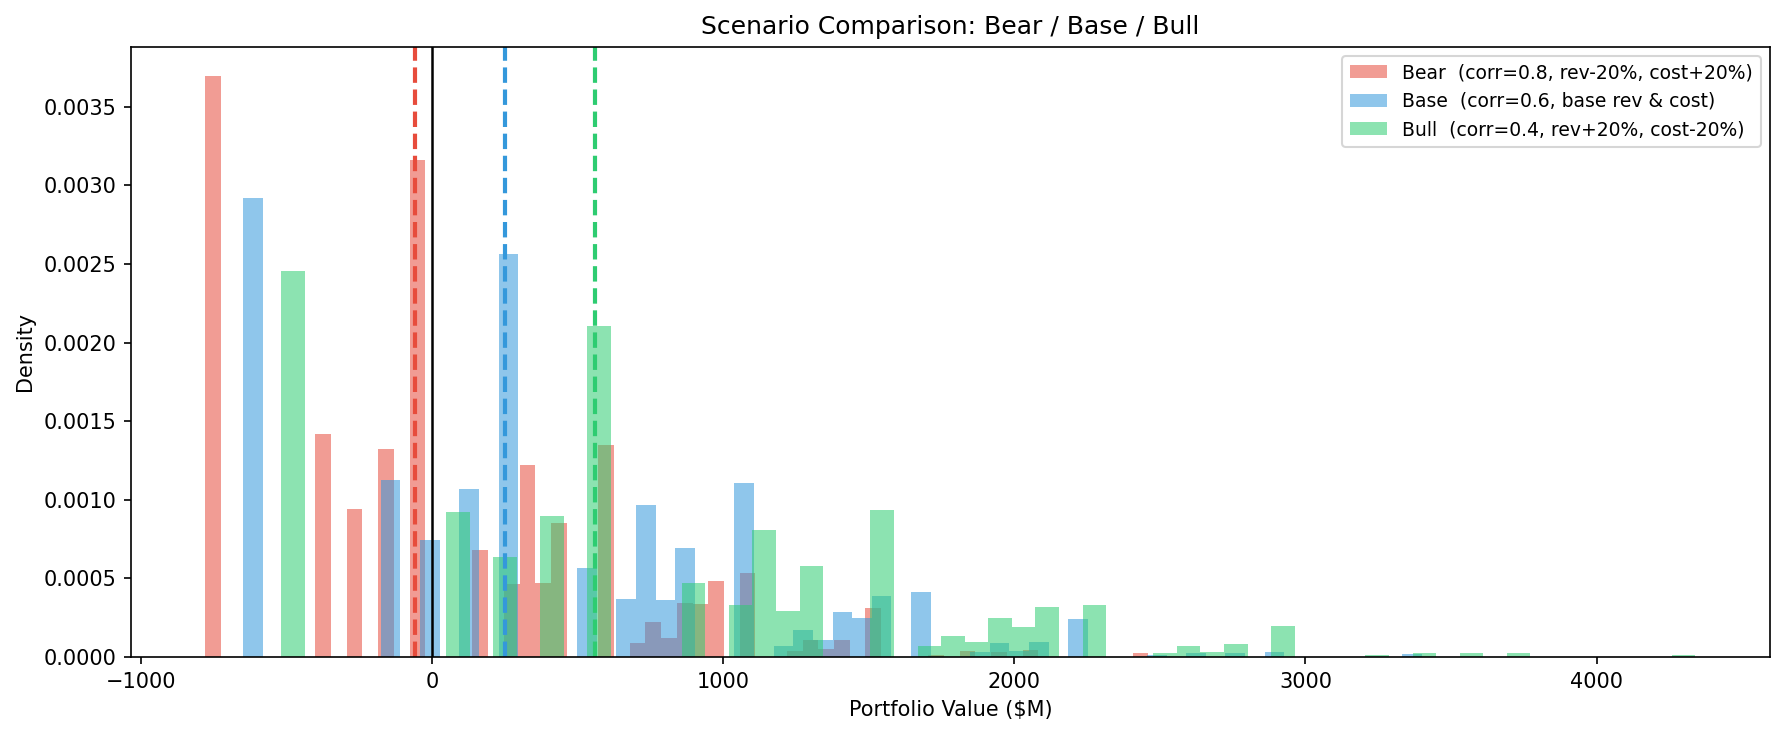

,Scenario,Median,P(positive),5th pct,95th pct,Swing vs Base
0,Bear,-$60M,43%,-$780M,$1.1B,-$310M
1,Base,$250M,68%,-$650M,$1.7B,$0M
2,Bull,$560M,80%,-$520M,$2.3B,$310M


In [12]:
groups = df['correlation_group'].values
st = stress_test(alpha_post, beta_post, groups, revenue, cost, n_sims=8000)

def fmt(v):
    neg = v < 0
    av = abs(v)
    s = f'{chr(36)}{av/1000:.1f}B' if av >= 1000 else f'{chr(36)}{av:.0f}M'
    return f'-{s}' if neg else s

base_pv = st['base_pv']

# Helper: build one tornado panel for a given percentile stat
def tornado_panel(ax, stat_fn, base_val, title):
    factors = st['factors']
    labels = list(factors.keys())
    lo_vals = np.array([stat_fn(v[0]) for v in factors.values()])
    hi_vals = np.array([stat_fn(v[1]) for v in factors.values()])
    swings = hi_vals - lo_vals
    order = np.argsort(np.abs(swings))
    labels_ord = [labels[i] for i in order]
    lo_ord = lo_vals[order]
    hi_ord = hi_vals[order]

    y = np.arange(len(labels_ord))
    lo_swing = lo_ord - base_val
    hi_swing = hi_ord - base_val

    ax.barh(y, lo_swing, left=0, color='#e74c3c', alpha=0.85, height=0.5)
    ax.barh(y, hi_swing, left=0, color='#2ecc71', alpha=0.85, height=0.5)
    ax.axvline(0, color='black', linewidth=1.2)
    for i, (lo, hi) in enumerate(zip(lo_swing, hi_swing)):
        ax.text(lo - 3, i, fmt(lo_ord[i]), va='center', ha='right', fontsize=8)
        ax.text(hi + 3, i, fmt(hi_ord[i]), va='center', ha='left', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels_ord, fontsize=8)
    ax.set_xlabel(f'Swing from base ({fmt(base_val)})', fontsize=8)
    ax.set_title(title, fontsize=10)
    # Expand xlim so bar-end labels don't collide with y-axis tick labels
    span = max(hi_swing.max() - lo_swing.min(), 1)
    ax.set_xlim(lo_swing.min() - span * 0.30, hi_swing.max() + span * 0.20)

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=False)

tornado_panel(axes[0], np.median,
              np.median(base_pv),
              'Median portfolio value')
tornado_panel(axes[1], lambda pv: np.percentile(pv, 5),
              np.percentile(base_pv, 5),
              '5th percentile  (worst 5% of outcomes)')
tornado_panel(axes[2], lambda pv: np.percentile(pv, 95),
              np.percentile(base_pv, 95),
              '95th percentile  (best 5% of outcomes)')

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(color='#e74c3c', alpha=0.85, label='Low assumption'),
                   Patch(color='#2ecc71', alpha=0.85, label='High assumption')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Tornado: Sensitivity of Portfolio Value to Key Assumptions', fontsize=12)
fig.tight_layout()
fig.savefig('plots/stress_test_tornado.png', bbox_inches='tight')
plt.show()

# --- Scenario distributions ---
fig, ax = plt.subplots(figsize=(12, 5))
scenario_colors = {'Bear': '#e74c3c', 'Base': '#3498db', 'Bull': '#2ecc71'}
scenario_labels = {
    'Bear': 'Bear  (corr=0.8, rev-20%, cost+20%)',
    'Base': 'Base  (corr=0.6, base rev & cost)',
    'Bull': 'Bull  (corr=0.4, rev+20%, cost-20%)',
}
for name, pv in st['scenarios'].items():
    ax.hist(pv, bins=60, alpha=0.55, color=scenario_colors[name],
            label=scenario_labels[name], density=True)
    ax.axvline(np.median(pv), color=scenario_colors[name], linewidth=2, linestyle='--')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel(f'Portfolio Value ({chr(36)}M)')
ax.set_ylabel('Density')
ax.set_title('Scenario Comparison: Bear / Base / Bull')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig('plots/stress_test_scenarios.png', bbox_inches='tight')
plt.show()

# --- Summary table ---
rows = []
for name, pv in st['scenarios'].items():
    rows.append({
        'Scenario': name,
        'Median': fmt(np.median(pv)),
        'P(positive)': f'{(pv > 0).mean():.0%}',
        '5th pct': fmt(np.percentile(pv, 5)),
        '95th pct': fmt(np.percentile(pv, 95)),
        'Swing vs Base': fmt(np.median(pv) - np.median(base_pv)),
    })
display(pd.DataFrame(rows))